# Applied Exercise 8 - Simple Linear Regression on Auto Dataset

#### Objective - perform a simple linear regression using the Auto dataset.

The goal is to predict `mpg` (miles per gallon) using the predictor variable: `horsepower` using the ordinary least squares (OLS) regression model.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from ISLP import load_data

In [6]:
Auto = load_data("Auto")

Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [7]:
Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


In [9]:
X = sm.add_constant(Auto["horsepower"])
y = Auto["mpg"]

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           7.03e-81
Time:                        20:09:07   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretation of Regression Output

#### 1. Relationship between predictor and response

The p-value associated with horsepower indicates whether there is statistically significant evidence of a relationship between horsepower and mpg (<0.0001)

#### 2. Strength of relationship

The strength of the relationship can be assessed using R-squared ($R^2$). Here it is 0.606 which says around 60% of variability is explained by the model.

#### 3. Direction of relationship

The sign of the horsepower coefficient determines the direction. Here we have a negative coefficient → mpg decreases as horsepower increases.

In [10]:
new_car = pd.DataFrame({"const": [1], "horsepower": [98]})

prediction = model.get_prediction(new_car)
prediction.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,24.467077,0.251262,23.973079,24.961075,14.809396,34.124758


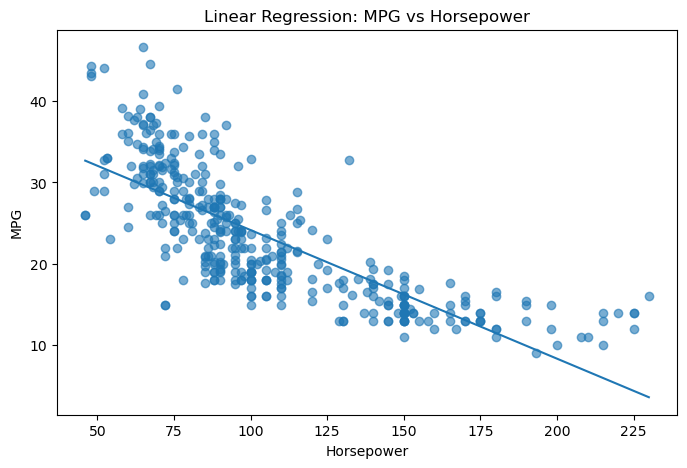

In [11]:
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(
    Auto["horsepower"],
    Auto["mpg"],
    alpha=0.6
)

x_range = np.linspace(
    Auto["horsepower"].min(),
    Auto["horsepower"].max(),
    100
)

X_line = sm.add_constant(x_range)

y_pred = model.predict(X_line)

ax.plot(
    x_range,
    y_pred
)

ax.set_xlabel("Horsepower")
ax.set_ylabel("MPG")
ax.set_title("Linear Regression: MPG vs Horsepower")

plt.show()

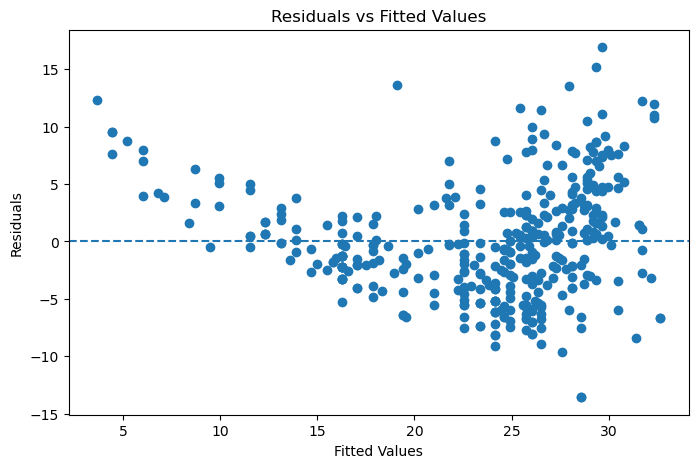

In [12]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8,5))

plt.scatter(fitted, residuals)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

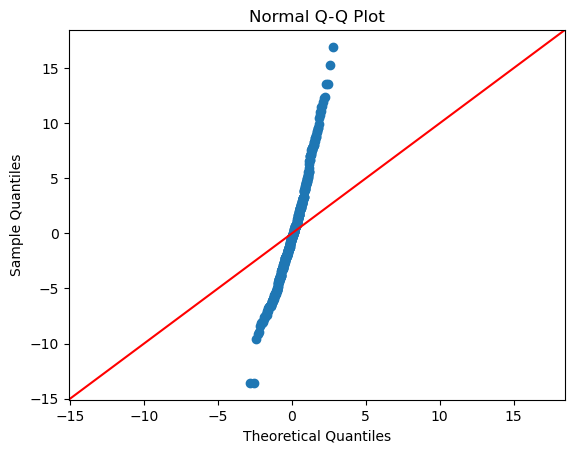

In [13]:
sm.qqplot(
    residuals,
    line="45"
)

plt.title("Normal Q-Q Plot")

plt.show()

Key observations

- Horsepower is statistically significant in predicting mpg.
- The relationship is negative, indicating that cars with higher horsepower generally have lower fuel efficiency.
- The residuals vs fitted values plot shows a clear pattern rather than random scatter around zero. This suggests that the relationship between horsepower and mpg may not be completely linear. Adding terms like polynomials may improve the model.
- The Q-Q plot shows considerable deviation from the 45-degree reference line, particularly at the tails indicating that the residuals are not  normally distributed. The deviations suggests skewness or the presence of outliers that affect the normality assumption of the linear regression model.